# Project Python Foundations: FoodHub Data Analysis

### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost_of_the_order: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [12]:
# Installing the libraries with the specified version.
!pip install numpy==1.25.2 pandas==1.5.3 matplotlib==3.7.1 seaborn==0.13.1 -q --user

**Note**: *After running the above cell, kindly restart the notebook kernel and run all cells sequentially from the start again.*

In [13]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# importing warnings package
# because some of my code showing warnings on the graphs for some deprecated functions and properties I was using to generate the graphs
import warnings
warnings.filterwarnings("ignore")

### Understanding the structure of the data

In [14]:
# uncomment and run the following lines for Google Colab
#from google.colab import drive
#drive.mount('/content/foodhub_order.csv')

# Please note that I uploaded the foodhub_order.csv file to the Notebook manually instead of connecting my google drive
file_path = '/content/foodhub_order.csv'
df = pd.read_csv(file_path)


In [15]:
# Write your code here to read the data

# Using to_string() function to avoid any line breaks in my output and make it readable
print(df.to_string())

      order_id  customer_id                        restaurant_name    cuisine_type  cost_of_the_order day_of_the_week     rating  food_preparation_time  delivery_time
0      1477147       337525                                Hangawi          Korean              30.75         Weekend  Not given                     25             20
1      1477685       358141              Blue Ribbon Sushi Izakaya        Japanese              12.08         Weekend  Not given                     25             23
2      1477070        66393                            Cafe Habana         Mexican              12.23         Weekday          5                     23             28
3      1477334       106968              Blue Ribbon Fried Chicken        American              29.20         Weekend          3                     25             15
4      1478249        76942                       Dirty Bird to Go        American              11.59         Weekday          4                     25             2

In [16]:
# Write your code here to view the first 5 rows

# Using head() function to get first 5 rows and then converting each row to string
print(df.head().to_string())

   order_id  customer_id            restaurant_name cuisine_type  cost_of_the_order day_of_the_week     rating  food_preparation_time  delivery_time
0   1477147       337525                    Hangawi       Korean              30.75         Weekend  Not given                     25             20
1   1477685       358141  Blue Ribbon Sushi Izakaya     Japanese              12.08         Weekend  Not given                     25             23
2   1477070        66393                Cafe Habana      Mexican              12.23         Weekday          5                     23             28
3   1477334       106968  Blue Ribbon Fried Chicken     American              29.20         Weekend          3                     25             15
4   1478249        76942           Dirty Bird to Go     American              11.59         Weekday          4                     25             24


### **Question 1:** How many rows and columns are present in the data? [0.5 mark]

In [17]:
# Getting total number of rows using shape property of DataFrame
rows, cols = df.shape

# Print the number of rows and columns
print(f"Total Number of rows: {rows}")
print(f"Total Number of columns: {cols}")

Total Number of rows: 1898
Total Number of columns: 9


#### Observations:


*   This dataset has 1898 total number of records loaded from the csv
*   There are total 9 attributes exist in this data set
*   This data does not have the order dates so thats something I would say if we had in there, that could have helped more in terms of performance analysis.


### **Question 2:** What are the datatypes of the different columns in the dataset? (The info() function can be used) [0.5 mark]

In [18]:
# Getting data type of all columns using dtypes function of df

df.dtypes

# We could also do print(df.info()) which will also show the information about data types in a little different format

,0
order_id,int64
customer_id,int64
restaurant_name,object
cuisine_type,object
cost_of_the_order,float64
day_of_the_week,object
rating,object
food_preparation_time,int64
delivery_time,int64


**Observations:**


*   It is a dataset having mix of different data types
*   order_id must be unique in this data set
*   The rest of the fields can have duplicates



### **Question 3:** Are there any missing values in the data? If yes, treat them using an appropriate method. [1 mark]

In [19]:
'''
I am assuming missing values in the data means null values and if I run the below code, there are no null values in this data set.
Therefore, we do not need to perform any treatment on missing values.
'''

# isnull() function checks for null values for each data column in the dataset and we count the occurences with the help of sum() function
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


**Observations:**



*   There are no null values in any column of the dataset
*   This is good thing about this dataset and we will not have to impute any value for any attribute in this dataset
*   However, when it comes to Rating column, even though it doesn't have any null values, it does have records with value "Not given", this means lots of orders did not get any rating and we will have to handle those values in our calculation when we are doing any statistical measure. I have show that in few questions in this assignment.





### **Question 4:** Check the statistical summary of the data. What is the minimum, average, and maximum time it takes for food to be prepared once an order is placed? [2 marks]

In [20]:
'''
For statistical summary, I am using the describe() function below which tries to calculate different statistical measures on all fields.
Here we can see that it has tried to run those measures on order_id and customer_id columns which do not make sense
but I just wanted to show how describe() function can be used.
'''

print(df.describe().to_string())

           order_id    customer_id  cost_of_the_order  food_preparation_time  delivery_time
count  1.898000e+03    1898.000000        1898.000000            1898.000000    1898.000000
mean   1.477496e+06  171168.478398          16.498851              27.371970      24.161749
std    5.480497e+02  113698.139743           7.483812               4.632481       4.972637
min    1.476547e+06    1311.000000           4.470000              20.000000      15.000000
25%    1.477021e+06   77787.750000          12.080000              23.000000      20.000000
50%    1.477496e+06  128600.000000          14.140000              27.000000      25.000000
75%    1.477970e+06  270525.000000          22.297500              31.000000      28.000000
max    1.478444e+06  405334.000000          35.410000              35.000000      33.000000


In [21]:
# Below I am further calculating the actual statistical measures asked in the question

min_time = df['food_preparation_time'].min()
avg_time = df['food_preparation_time'].mean()
max_time = df['food_preparation_time'].max()

print(f"Minimum time taken to prepare food: {min_time} minutes")
print(f"Average time taken to prepare food: {avg_time} minutes")
print(f"Maximum time taken to prepare food: {max_time} minutes")

Minimum time taken to prepare food: 20 minutes
Average time taken to prepare food: 27.371970495258168 minutes
Maximum time taken to prepare food: 35 minutes


**Observations:**


1.   Based on the minimum, maximum and average we calculated above for "food_preparation_time", the dataset seem to be normally distributed to some extent for this particular attribute.
2.   The average is not too far away from minimum and maximum values of "food_preparation_time" and that represents that more or less every order takes 27 minutes to be prepared.



### **Question 5:** How many orders are not rated? [1 mark]

In [22]:
# Calculating the count of all rows where rating column is equal to 'Not given'
count_rating_not_given = (df['rating'] == 'Not given').sum()

# Printing the count
print(f"Ordes Not Rated: {count_rating_not_given}")

Ordes Not Rated: 736


**Observations:**



*   736 orders without rating is a huge number.
*   The business is not doing great in terms of getting feedback and ratings from their customers.
*   Business should probably analyze if there is a pattern among the order who are not rated and if there is one, should focus on solving them so that we can start getting ratings in future.





### Exploratory Data Analysis (EDA)

### Univariate Analysis

### **Question 6:** Explore all the variables and provide observations on their distributions. (Generally, histograms, boxplots, countplots, etc. are used for univariate exploration.) [9 marks]

Please note that there are total 9 variables out of which the following two are kind of unique identifiers (like a primary key in a database table) and do not carry meaningful NUMERICAL or CATEGORICAL information for plotting.



1.   order_id
2.   customer_id



Therefore, we will not be plottiing these 2 directly but they will be used as totals in different visualizations when it comes to analyze something based on the total number of orders or customers.

# **EXPLORING NUMERICAL VARIABLES**

Let us first explore the numerical variables.

In this data set, the numerical variables are:

  1. cost_of_the_order
  2. food_preparation_time
  3. delivery_time
  3. rating (after converting it to numeric to handle Not Rated values)  

We can check the distribution of observations by plotting following types of graphs:

  1. Histograms
  2. Boxplots
  3. Violin Plot
  3. KDE Plot (Kernel Density Estimation)



**1. Plotting cost_of_the_order**

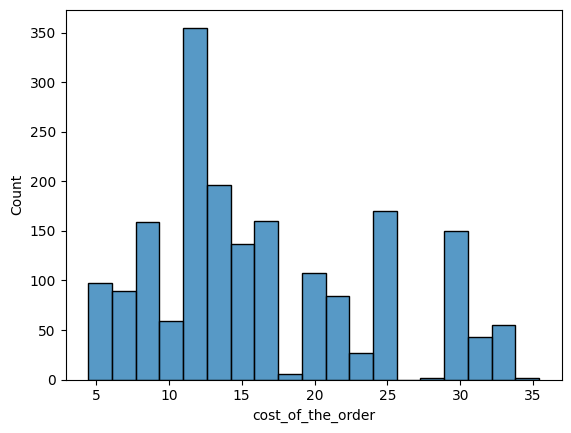

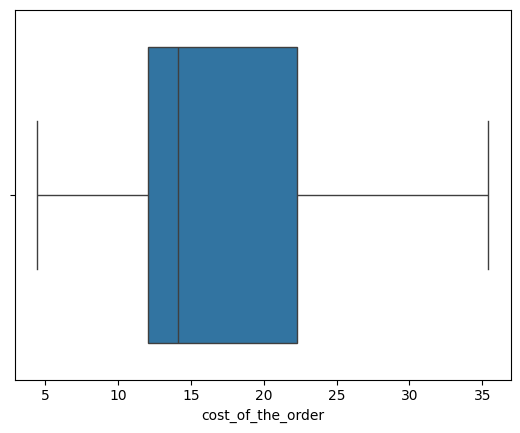

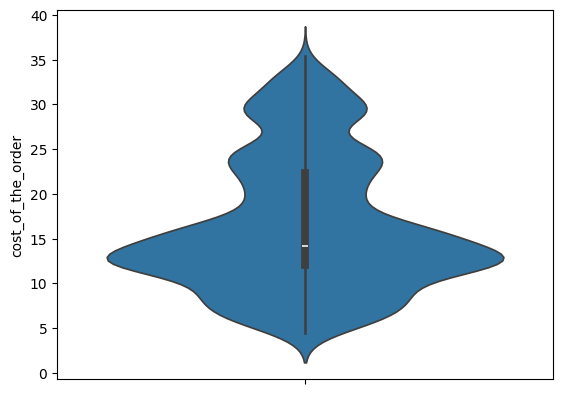

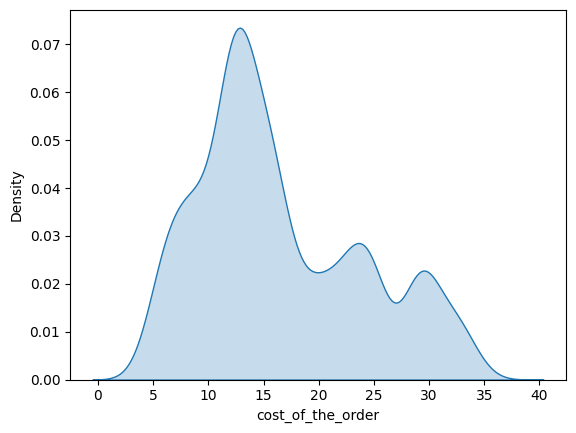

In [23]:
# Generating and printing the histogram
sns.histplot(data=df,x='cost_of_the_order')
plt.show()

# Generating and printing the boxplot
sns.boxplot(data=df,x='cost_of_the_order')
plt.show()

# Generating and printing the violinplot
sns.violinplot(y=df['cost_of_the_order'])
plt.show()

# Generating and printing the kdeplot
sns.kdeplot(df['cost_of_the_order'], fill=True)
plt.show()

**Observations:**

- *The distribution of cost_of_the_order is left skewed*
- *The orders between 10 dollars and 17 dollars are most frequent orders that customers have placed.*
- *While mostly the cost_of_the_order is on lower side under $17, we have observations where the orders went as high as 35 dollars*

**2. Plotting food_preparation_time**

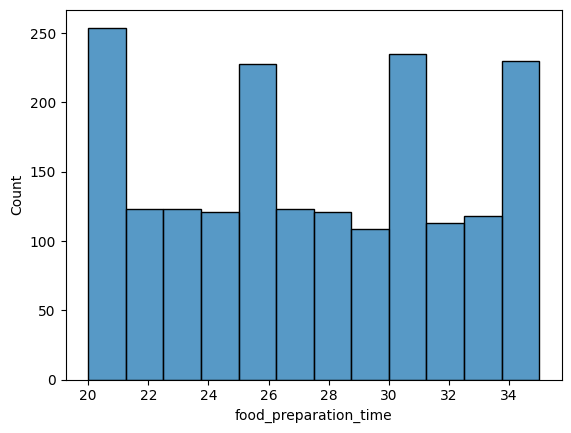

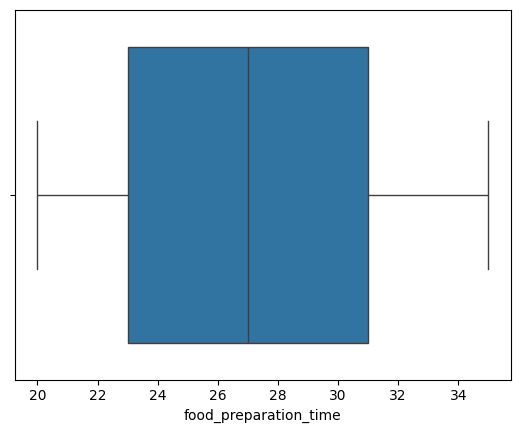

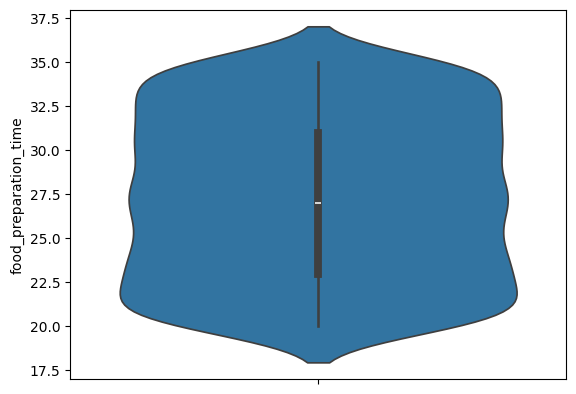

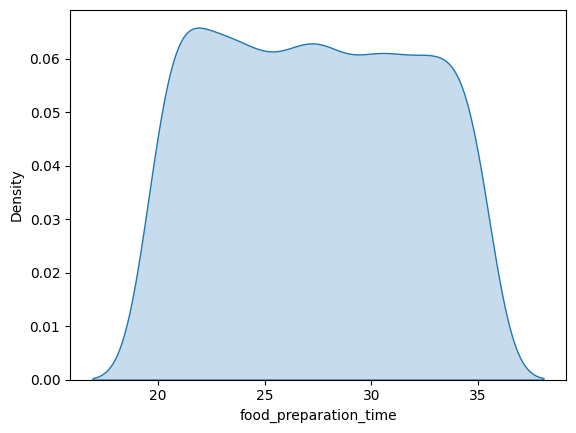

In [24]:
# Generating and printing the histogram
sns.histplot(data=df,x='food_preparation_time')
plt.show()

# Generating and printing the boxplot
sns.boxplot(data=df,x='food_preparation_time')
plt.show()

# Generating and printing the violinplot
sns.violinplot(y=df['food_preparation_time'])
plt.show()

# Generating and printing the kdeplot
sns.kdeplot(df['food_preparation_time'], fill=True)
plt.show()

**Observations:**

- *The distribution of food_prepation_time is mostly uniform distribution
- *There are few outliers in this variable*
- *We have orders count in the range of 100 and 125 almost equally distributed across different food preparation time.*

**3. Plotting delivery_time**

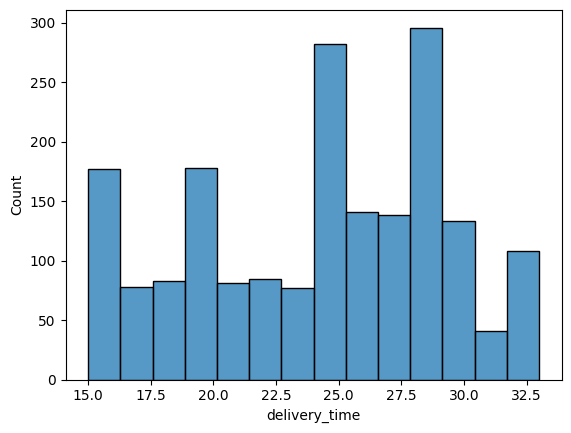

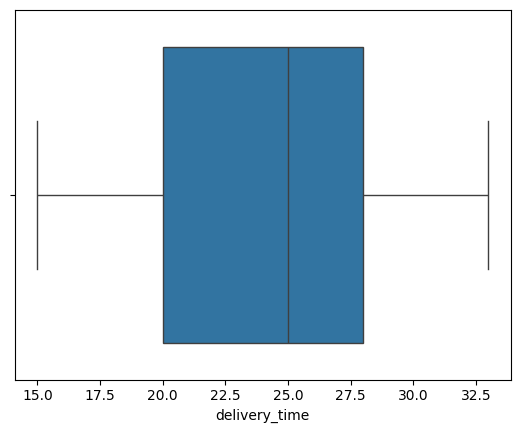

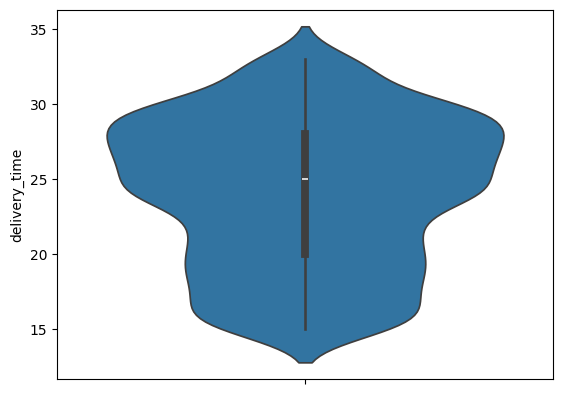

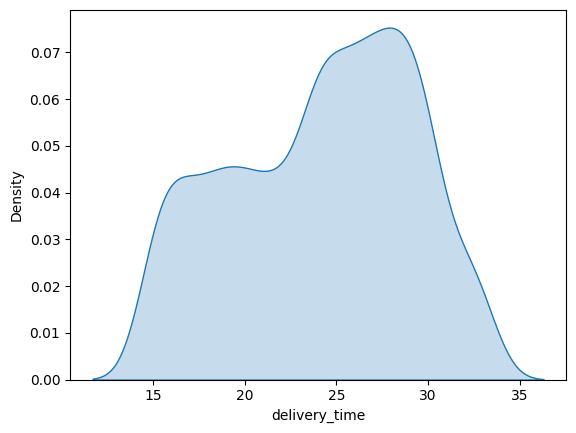

In [25]:
# Generating and printing the histogram
sns.histplot(data=df,x='delivery_time')
plt.show()

# Generating and printing the boxplot
sns.boxplot(data=df,x='delivery_time')
plt.show()

# Generating and printing the violinplot
sns.violinplot(y=df['delivery_time'])
plt.show()

# Generating and printing the kdeplot
sns.kdeplot(df['delivery_time'], fill=True)
plt.show()

**Observations:**

- *The distribution of delivery_time is right skewed*
- *Most of the orders take 25 to 30 minutes to deliver*
- *We have some orders like some outliers who have taken more than 32 minutes and thats something we should analyze deeper if it worth delivery that far if its due to distance or not.*

# **EXPLORING CATEGORICAL VARIABLES**


In this data set, the categorical variables are:

  1. restaurant_name
  2. cuisine_type
  3. day_of_the_week
  3. rating (even though we have covered it in Numerical variables we can still use it for categorical analysis for reference purpose)

**Bar Charts**

Bar Charts can be used to explore the distribution of Categorical Variables.

Each entity of the categorical variable is represented as a bar.

The size of the bar represents its numeric value.


**1. Plotting restaurant_name**

<Axes: xlabel='restaurant_name', ylabel='count'>

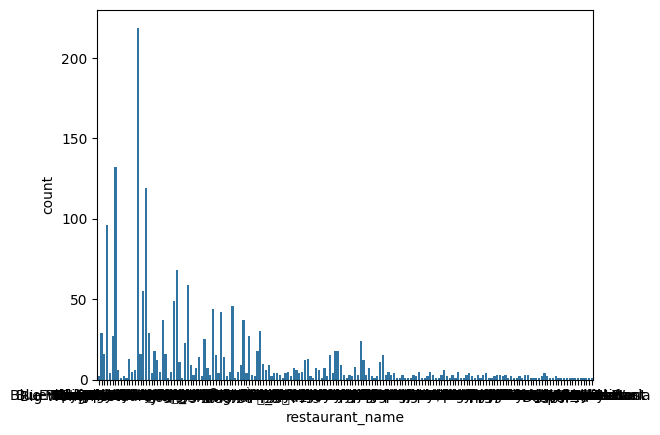

In [26]:
# Generating and printing the bar chart
sns.countplot(data=df, x='restaurant_name')

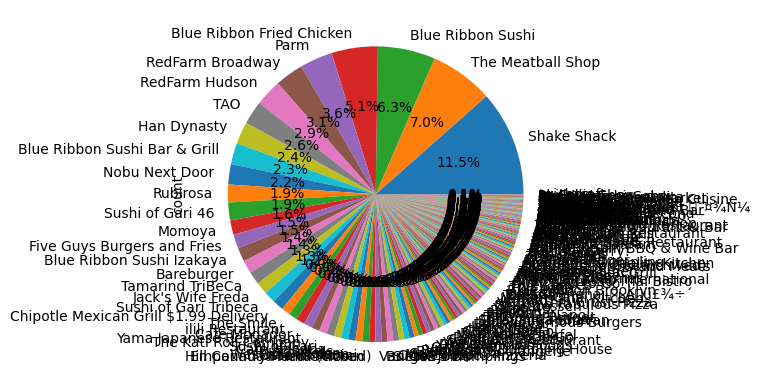

In [ ]:
# Generating and printing the pie chart
df['restaurant_name'].value_counts().plot.pie(autopct="%1.1f%%")
plt.show()

**Observations:**

- *The distribution of order by restaurant names is highly left skewed*
- *Only few restaurants are having significantly high number of orders*
- *There are lots of restaurants who have very few orders and that something to analyze deeper if those restaurants are worth running if they are not giving a good amount of business*

**2. Plotting cuisine_type**

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13],
 [Text(0, 0, 'Korean'),
  Text(1, 0, 'Japanese'),
  Text(2, 0, 'Mexican'),
  Text(3, 0, 'American'),
  Text(4, 0, 'Indian'),
  Text(5, 0, 'Italian'),
  Text(6, 0, 'Mediterranean'),
  Text(7, 0, 'Chinese'),
  Text(8, 0, 'Middle Eastern'),
  Text(9, 0, 'Thai'),
  Text(10, 0, 'Southern'),
  Text(11, 0, 'French'),
  Text(12, 0, 'Spanish'),
  Text(13, 0, 'Vietnamese')])

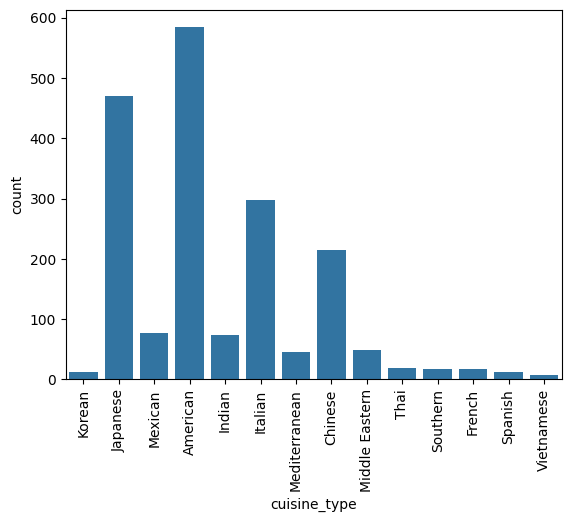

In [27]:
# Generating and printing the bar chart
sns.countplot(data=df, x='cuisine_type')
plt.xticks(rotation = 90)

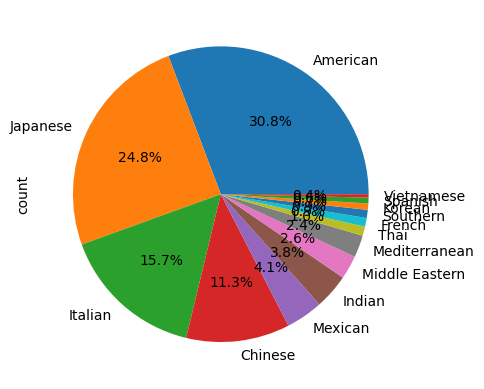

In [28]:
# Generating and printing the pie chart
df['cuisine_type'].value_counts().plot.pie(autopct="%1.1f%%")
plt.show()

**Observations:**

- *The distribution of cuisine type is highly left skewed*
- *The American, Japenese, Italian and then Chinese cuisines are dominating the buisness*
- *There is some support from Mexican and Mediterranean but other cuistine_type are not doing good at all*

**3. Plotting day_of_the_week**

<Axes: xlabel='day_of_the_week', ylabel='count'>

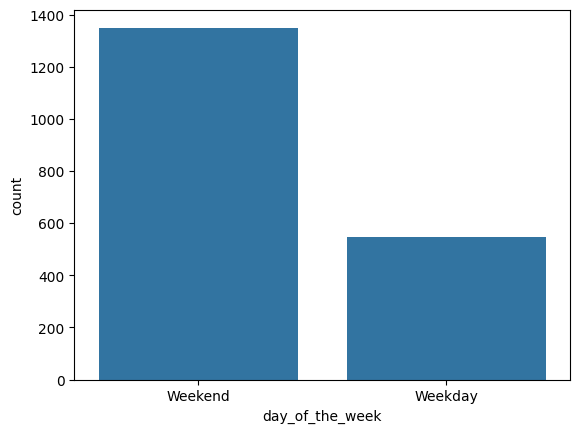

In [29]:
# Generating and printing the bar chart
sns.countplot(data=df, x='day_of_the_week')

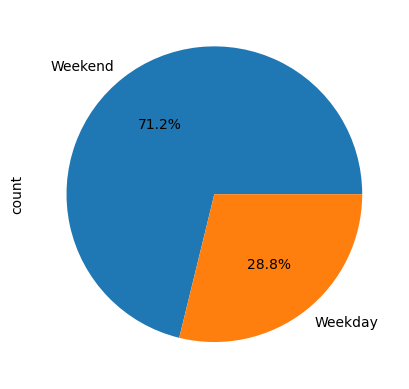

In [30]:
# Generating and printing the pie chart
df['day_of_the_week'].value_counts().plot.pie(autopct="%1.1f%%")
plt.show()

**Observations:**

- *The weekends are clearly doing great as there is more than 70% of orders are on weekends*


**4. Plotting rating**

<Axes: xlabel='rating', ylabel='count'>

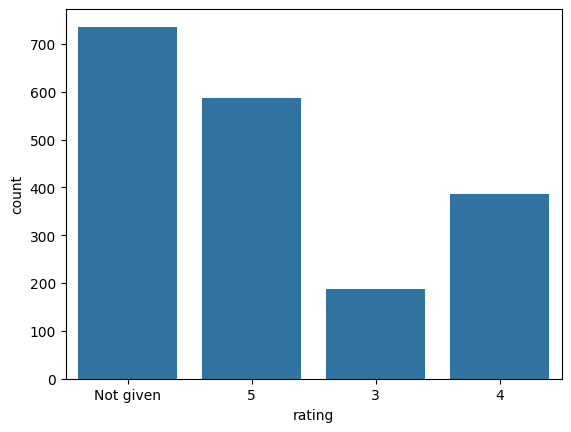

In [31]:
# Generating and printing the bar chart
sns.countplot(data=df, x='rating')

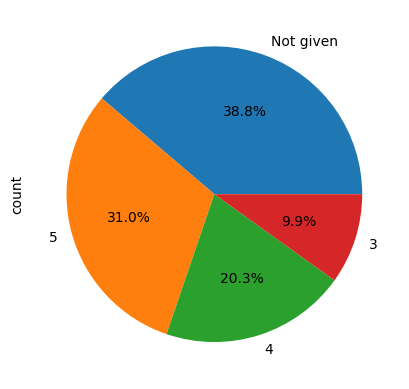

In [32]:
# Generating and printing the pie chart
df['rating'].value_counts().plot.pie(autopct="%1.1f%%")
plt.show()

**Observations:**

- *There is a good numbrer of rating captured across 3, 4 and 5*
- *However still the majority of the orders are not rated at all and therefore business should introduce some offers or discounts to get more ratings which will eventually help the business.*

### **Question 7**: Which are the top 5 restaurants in terms of the number of orders received? [1 mark]

In [33]:
# Group by restaurant_name and cuisine_type, count number of orders
top_restaurants = (
    df.groupby(['restaurant_name', 'cuisine_type'])
    .size()  # Count number of orders
    .reset_index(name='order_count')  # Rename the count column
    .sort_values(by='order_count', ascending=False)  # Sort in descending order
    .head(5)  # Get top 5
)

# Add a ranking column
top_restaurants['Rank'] = range(1, len(top_restaurants) + 1)

# Reorder columns to show Rank first
top_restaurants = top_restaurants[['Rank', 'restaurant_name', 'cuisine_type', 'order_count']]

# Display results
print(top_restaurants.to_string(index=False))

 Rank           restaurant_name cuisine_type  order_count
    1               Shake Shack     American          219
    2         Blue Ribbon Sushi     Japanese          119
    3         The Meatball Shop      Italian          112
    4 Blue Ribbon Fried Chicken     American           96
    5                      Parm      Italian           68


#### Observations:
This shows that American, Japenese and Italian cuisines are definitely in demand and doing the most in terms of top 5 restaurants.

### **Question 8**: Which is the most popular cuisine on weekends? [1 mark]

In [34]:
'''
The most popular cuisine on weekends is the one with highest orders on weekends.
Therefore, first creating a data frame for rows with day_of_the_week = Weekend
and then counting rows for each cuisine in that data frame.
Finally applying the head(1) function to get the one with highest count which is our popular cuisine
'''

# Filter the data for 'day_of_the_week' = 'Weekend' and create a new df
weekend_df = df[df['day_of_the_week'].isin(['Weekend'])]

# Count the number of occurrences of each cuisine_type on weekends
# And then calling head(1) on it to get the one with highest count which is our popular cuisine
# popular_cuisine becomes a variable for the data set
# It holds the one single top cuisine type as the index and its corresponding orders count as its value
popular_cuisine = weekend_df['cuisine_type'].value_counts().head(1)

# Printing a custom label for our output
# Also fetching the index and values from 0th position/index of the popular_cuisine
print(f"Most Popular Cuisine on weekends is {popular_cuisine.index[0]} with {popular_cuisine.values[0]} orders.")

Most Popular Cuisine on weekends is American with 415 orders.


#### Observations:
- American food is in hot demand over the weekend.

### **Question 9**: What percentage of the orders cost more than 20 dollars? [2 marks]

In [35]:
'''
The idea here is to first count all the orders whose cost is greater than 20 dollars
and then divide it by total number of orders to get the percentage
'''

# Filter orders with cost more than $20
orders_above_20 = df[df['cost_of_the_order'] > 20]

# Calculate the percentage of orders with cost more than $20
# Here numerator is len(orders_above_20) which is actually the total number of orders having cost greater than $20
# And denomenator is len(df) which is the total number of orders
# And to get to the percentage, we multiply the result by 100 in the end
percentage_above_20 = (len(orders_above_20) / len(df)) * 100

print(f"Percentage of orders having cost of more than $20: {percentage_above_20:.2f}%")

Percentage of orders having cost of more than $20: 29.24%


#### Observations:
This indicates that its not too expensive as most of the spending is done under 20 dollars by almost 70% of the orders.

### **Question 10**: What is the mean order delivery time? [1 mark]

In [36]:
# Calculate the mean order delivery time
mean_delivery_time = df['delivery_time'].mean()

print(f"Mean Order Delivery Time: {mean_delivery_time:.2f} minutes")

Mean Order Delivery Time: 24.16 minutes


#### Observations:

This is a reasonable time but looks like either business is delivering to a larger radius or since most orders are on weekend so may be traffic is bad on weekends.

### **Question 11:** The company has decided to give 20% discount vouchers to the top 3 most frequent customers. Find the IDs of these customers and the number of orders they placed. [1 mark]

In [37]:
# Count the number of orders for each customer
# Note that reset_index() is used to remove any metadata from the output here
customer_order_counts = df['customer_id'].value_counts().reset_index()

# Rename the columns for clarity
customer_order_counts.columns = ['customer_id', 'order_count']

# Get the top 3 customers in terms of the number of orders received
top_3_customers = customer_order_counts.head(3)

# Set the index to start from 1 because if I don't do this, the output will list the 3 rows labeling them from 0 to 2
top_3_customers.index = range(1, len(top_3_customers) + 1)

# Print the top 3 customers with the number of orders
print("Top 3 most frequent customers and their number of orders:")
print(top_3_customers)

Top 3 most frequent customers and their number of orders:
   customer_id  order_count
1        52832           13
2        47440           10
3        83287            9


#### Observations:
Since the number of orders by top 3 customers is not too high, I would suggest to include more customers like may be 6 or 10 for better marketing and attracting more business.

### Multivariate Analysis

### **Question 12**: Perform a multivariate analysis to explore relationships between the important variables in the dataset. (It is a good idea to explore relations between numerical variables as well as relations between numerical and categorical variables) [10 marks]


To answer this question, I have visualized the dataset in following different Multivariate Dimensions:

1.   Average Delivery Time by Day of the Week
1.   Number of Orders by Restaurant Rating
1.   Number of Orders by Cuisine Type
1.   Delivery Time Distribution by Cuisine Type
1.   Average Food Preparation Time by Order Cost Range
1.   Average Order Cost by Cuisine Type
1.   Number of Orders by Restaurant, Rating, and Day of the Week
1.   Food Preparation Time by Cuisine Type and Rating
1.   Order Cost by Rating and Day of the Week
1.   Number of Customers by Cuisine Type
1.   Number of Customers by Rating
1.   Number of Customers by Restaurant Name
1.   Total Orders by Cuisine Type and Day of the Week
1.   Mean Delivery Time by Day of the Week
1.   Average Rating by Cuisine Type
1.   Average Cost by Cuisine Type (Line Plot)
1.   Average Food Preparation Time by Cuisine Type (Line Plot)
1.   Average Rating by Cuisine Type (Line Plot)
1.   Pair Plot of Food Preparation Time, Delivery Time, and Day of the Week



**1. Average Delivery Time by Day of the Week**


<Figure size 1200x600 with 0 Axes>

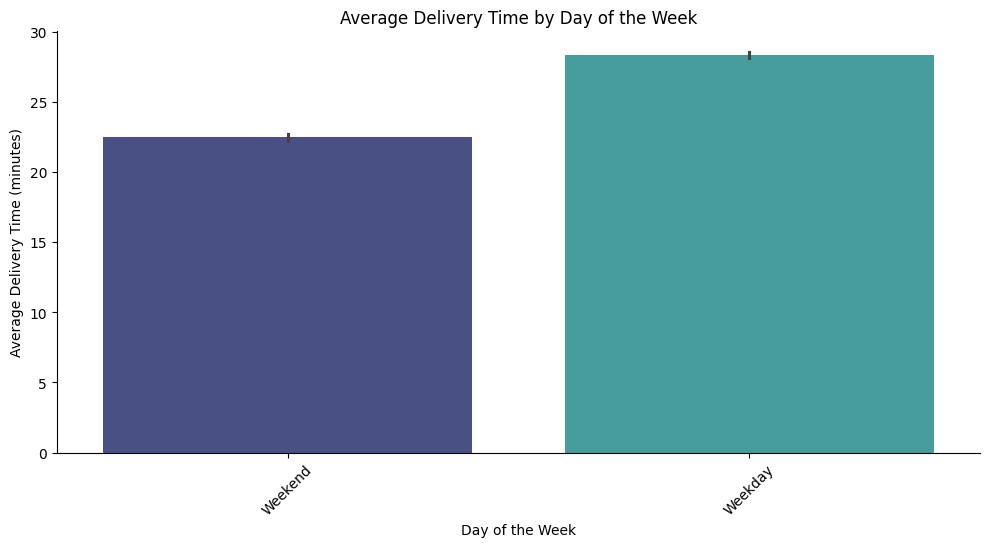

In [38]:
# Create an empty canvas for the graph
plt.figure(figsize=(12, 6))

# creates a categorical bar plot
sns.catplot(x="day_of_the_week", y="delivery_time", kind="bar", data=df, height=5, aspect=2, palette="mako")

# Title and labels
plt.xticks(rotation=45)
plt.title("Average Delivery Time by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Average Delivery Time (minutes)")
plt.show()

**Observations:**



*   Weekdays taking longer to deliver the order even though we have seen above that the number of orders are less on weekdays than weekends.
*   This indicates that due to a lot of business and public traffic over weekdays is causing more time to deliver the orders.



**2. Number of Orders by Restaurant Rating**

<Figure size 1000x500 with 0 Axes>

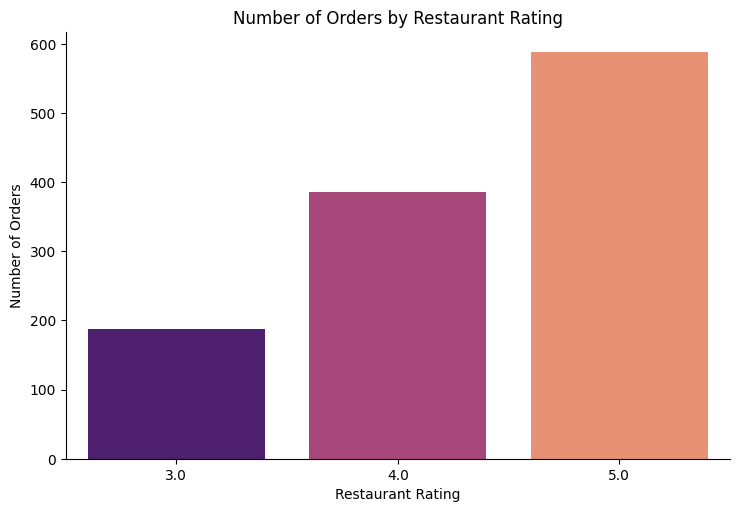

In [39]:
# Convert 'rating' column to numeric, ignoring "Not Rated"
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Group by rating and count the number of orders
rating_orders = df.groupby('rating')['order_id'].count().reset_index()

# Create an empty canvas for the graph
plt.figure(figsize=(10, 5))

# creates a categorical bar plot
sns.catplot(x="rating", y="order_id", kind="bar", data=rating_orders, height=5, aspect=1.5, palette="magma")

# Title and labels
plt.title("Number of Orders by Restaurant Rating")
plt.xlabel("Restaurant Rating")
plt.ylabel("Number of Orders")
plt.show()

**Observations:**
- On the ratings received, he business is doing prety good as most orders have been rated 5 and 4.

**3. Number of Orders by Cuisine Type**

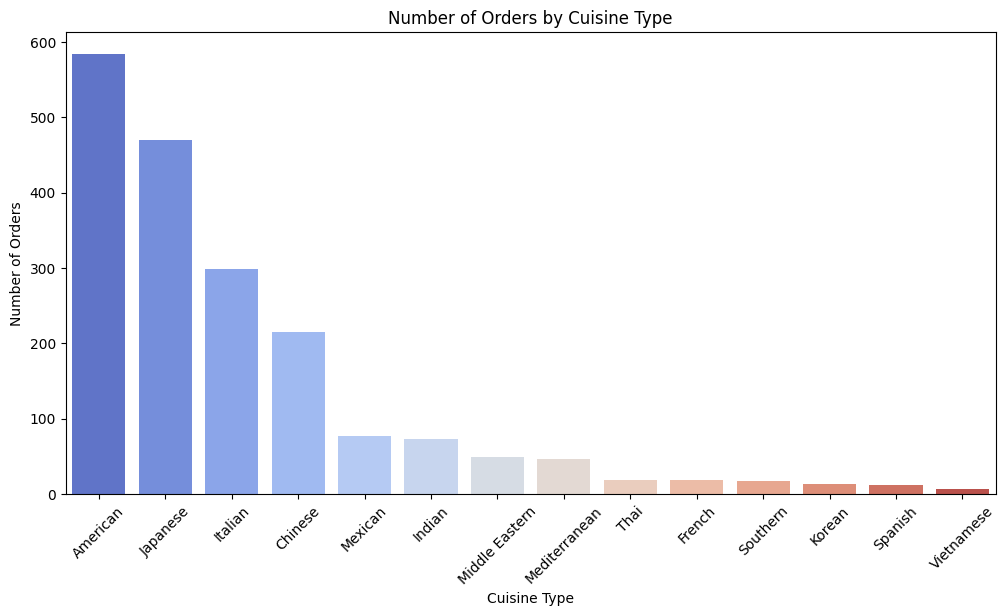

In [40]:
# Calculate the number of orders by cuisine type
order_counts = df['cuisine_type'].value_counts().reset_index()
order_counts.columns = ['cuisine_type', 'num_orders']

# Create an empty canvas for the graph
plt.figure(figsize=(12, 6))

# creates a bar plot
sns.barplot(x='cuisine_type', y='num_orders', data=order_counts, palette="coolwarm")

# Title and labels
plt.title("Number of Orders by Cuisine Type")
plt.xlabel("Cuisine Type")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.show()

**Observations:**
Like we saw in univariate analysis as well, American, Japenese, Italian and Chinese are the clear winners in terms of cuisine type.

**4. Delivery Time Distribution by Cuisine Type**

<Figure size 1200x600 with 0 Axes>

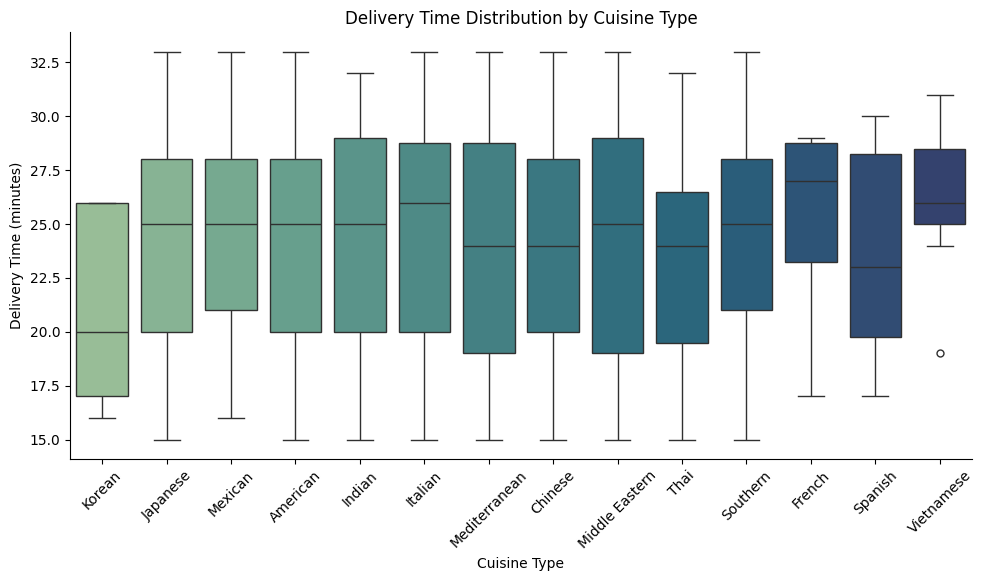

In [41]:
# Convert 'rating' column to numeric (ignoring "Not Rated")
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Create an empty canvas for the graph
plt.figure(figsize=(12, 6))

# creates a categorical box plot
sns.catplot(x="cuisine_type", y="delivery_time", kind="box", data=df, height=5, aspect=2, palette="crest")

# Title and labels
plt.xticks(rotation=45)
plt.title("Delivery Time Distribution by Cuisine Type")
plt.xlabel("Cuisine Type")
plt.ylabel("Delivery Time (minutes)")
plt.show()

**Observations:**
- The cusine type doesn't really matter in terms of delivery time and we can see that from the above box plot.
- Almost all cuisine types take 20 to 27 minutes to deliver.

**5. Average Food Preparation Time by Order Cost Range**

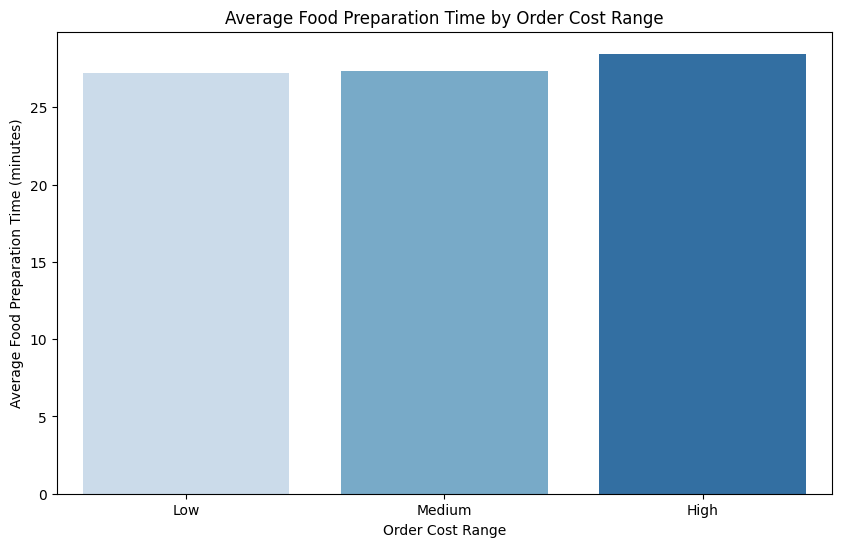

In [42]:
# Create a new column to categorize order cost into Low, Medium, High
bins = [0, 10, 30, float('inf')]  # Adjust bins based on your cost distribution
labels = ['Low', 'Medium', 'High']
df['cost_range'] = pd.cut(df['cost_of_the_order'], bins=bins, labels=labels)

# Calculate average food preparation time by cost range
avg_preparation_time = df.groupby('cost_range')['food_preparation_time'].mean().reset_index()

# Create an empty canvas for the graph
plt.figure(figsize=(10, 6))

# creates a bar plot
sns.barplot(x='cost_range', y='food_preparation_time', data=avg_preparation_time, palette="Blues")

# Title and labels
plt.title("Average Food Preparation Time by Order Cost Range")
plt.xlabel("Order Cost Range")
plt.ylabel("Average Food Preparation Time (minutes)")
plt.show()

**Observations:**
- If we create range of order costs like low, medium and high cost orders, we can see that there is no significant difference in food preparation time.
- This should be further analyzed why cheaper order is taking same amount of time is high price orders.

**6. Average Order Cost by Cuisine Type**

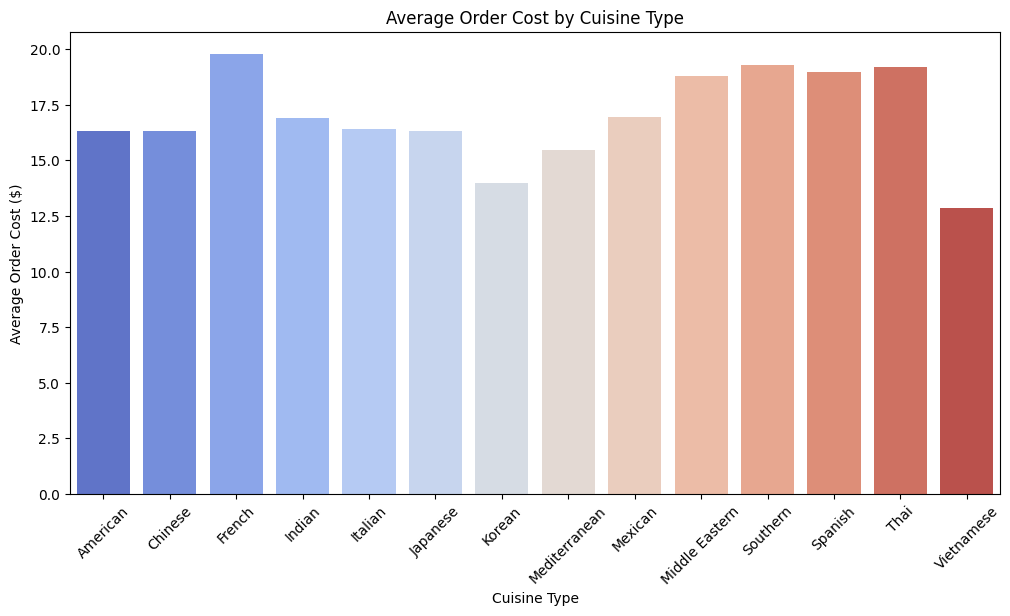

In [43]:
# Calculate the average order cost by cuisine type
avg_cost_by_cuisine = df.groupby('cuisine_type')['cost_of_the_order'].mean().reset_index()

# Create an empty canvas for the graph
plt.figure(figsize=(12, 6))

# Creates a bar plot
sns.barplot(x='cuisine_type', y='cost_of_the_order', data=avg_cost_by_cuisine, palette="coolwarm")

# Title and labels
plt.title("Average Order Cost by Cuisine Type")
plt.xlabel("Cuisine Type")
plt.ylabel("Average Order Cost ($)")
plt.xticks(rotation=45)
plt.show()

**Observations:**
- Every cuisine type falls in the same price range as per the average cost of orders.
- There are no outliers I would say.

**7. Number of Orders by Restaurant, Rating, and Day of the Week**

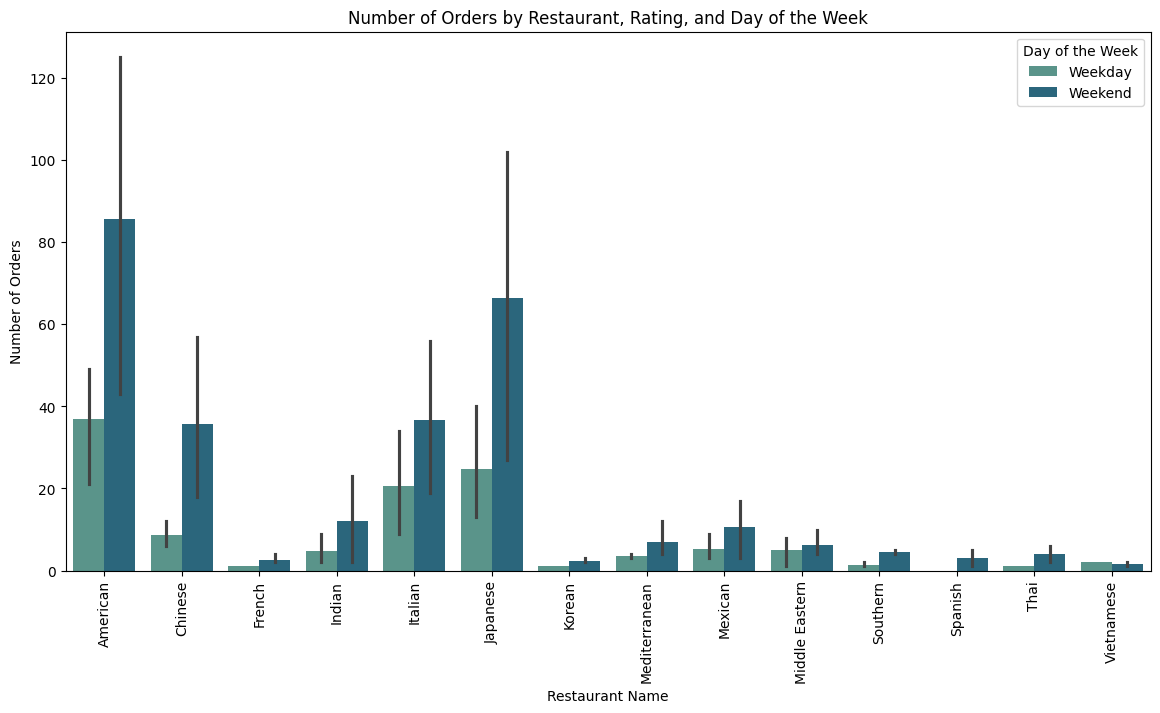

In [44]:
# Group by restaurant, day of the week, and rating to count the number of orders
order_counts = df.groupby(['cuisine_type', 'day_of_the_week', 'rating'])['order_id'].count().reset_index()

# Create an empty canvas for the graph
plt.figure(figsize=(14, 7))

# Creates a bar plot
sns.barplot(x='cuisine_type', y='order_id', hue='day_of_the_week', data=order_counts, palette='crest')

# Title and labels
plt.title("Number of Orders by Restaurant, Rating, and Day of the Week")
plt.xlabel("Restaurant Name")
plt.ylabel("Number of Orders")
plt.xticks(rotation=90)  # Rotate x-axis labels for readability
plt.legend(title="Day of the Week", bbox_to_anchor=(1, 1))
plt.show()

**Observations:**
- Few restaurants are clearly getting more ratings.
- We can also see that orders on the weekends have been rated more as compared to order over weekdays.

**8. Food Preparation Time by Cuisine Type and Rating**

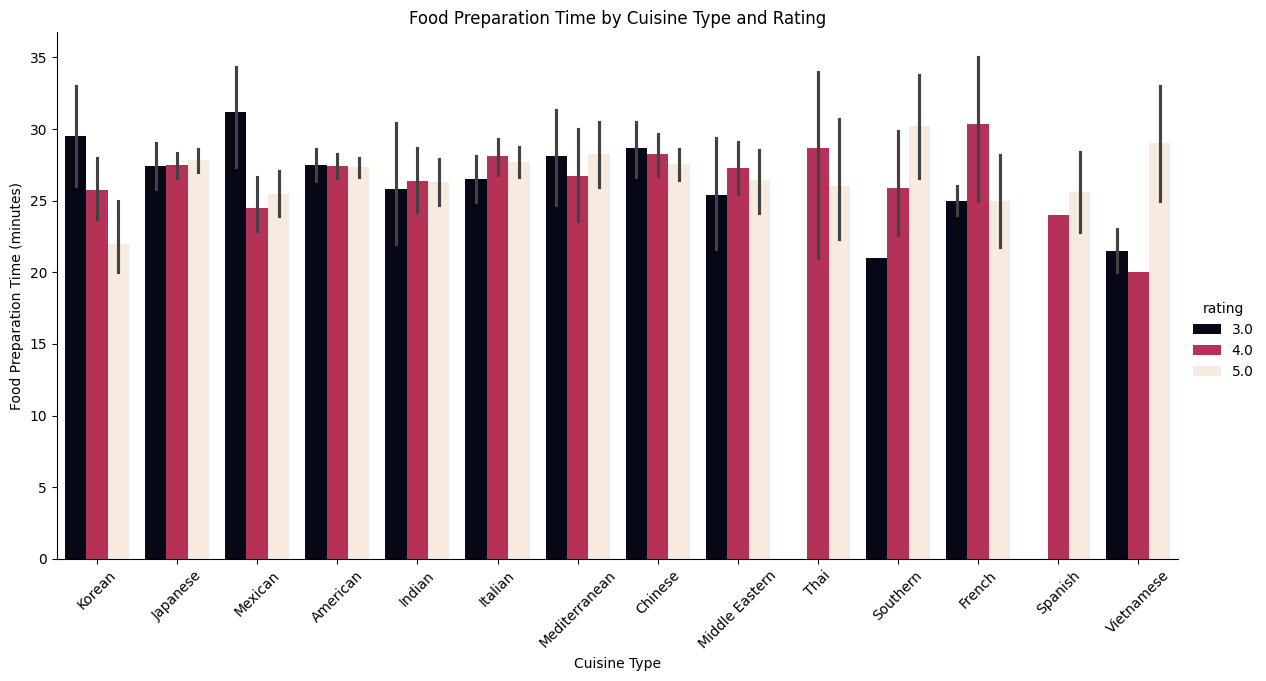

In [45]:
# creates a categorical bar plot
sns.catplot(x="cuisine_type", y="food_preparation_time", hue="rating", kind="bar", data=df, height=6, aspect=2, palette="rocket")

# Title and labels
plt.title("Food Preparation Time by Cuisine Type and Rating")
plt.xlabel("Cuisine Type")
plt.ylabel("Food Preparation Time (minutes)")
plt.xticks(rotation=45)
plt.show()

**Observations:**
- We can see that orders taking more time to prepare are missing out on ratings.
- For example if you look at Thai, Spanish and Vietnamese Cuisines, they are taking more than 25 minutes to prepare and hence people are not even rating them.

**9. Order Cost by Rating and Day of the Week**

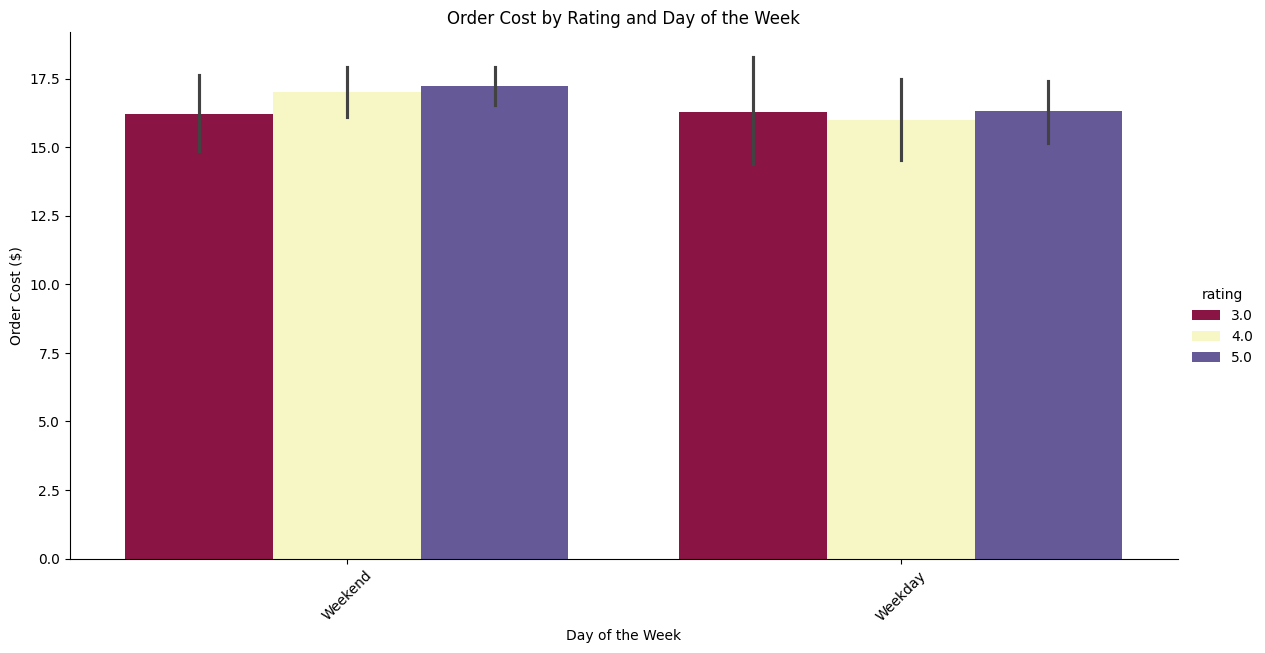

In [46]:
# creates a categorical bar plot
sns.catplot(x="day_of_the_week", y="cost_of_the_order", hue="rating", kind="bar", data=df, height=6, aspect=2, palette="Spectral")

# Title and labels
plt.title("Order Cost by Rating and Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Order Cost ($)")
plt.xticks(rotation=45)
plt.show()

**Observations:**
- It looks like the cost of the orders and day of the week do not impact much on the ratings.

**10. Number of Customers by Cuisine Type**

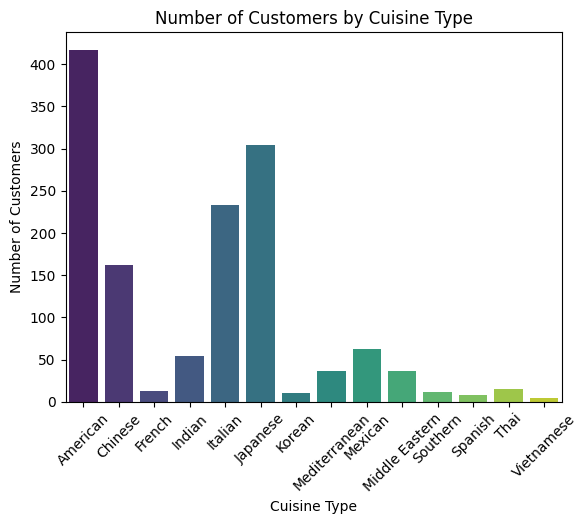

In [47]:
# Count the number of unique customers by cuisine type
customer_counts = df.groupby('cuisine_type')['customer_id'].nunique().reset_index()

# Creates a bar plot
sns.barplot(x='cuisine_type', y='customer_id', data=customer_counts, palette="viridis")

# Title and labels
plt.title("Number of Customers by Cuisine Type")
plt.xlabel("Cuisine Type")
plt.ylabel("Number of Customers")
plt.xticks(rotation=45)
plt.show()

**Observations:**
- Most customers like American cuisine.
- While we have decent demand for Japenese, Italian and Chinese cuisines.
- This distribution is highly left skewed.

**11. Number of Customers by Rating**

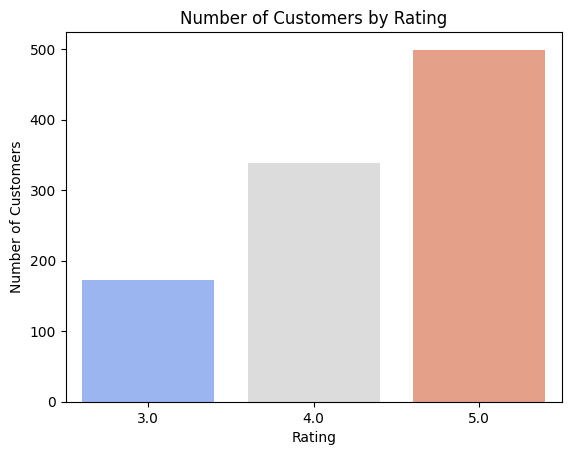

In [48]:
# Count the number of unique customers by rating
customer_counts_by_rating = df.groupby('rating')['customer_id'].nunique().reset_index()

# Create a bar plot (count plot) to visualize the number of customers by rating
sns.barplot(x='rating', y='customer_id', data=customer_counts_by_rating, palette="coolwarm")

# Title and labels
plt.title("Number of Customers by Rating")
plt.xlabel("Rating")
plt.ylabel("Number of Customers")
plt.show()

**Observations:**
- We have mostly happy customers as we can see the top rating we have achieved is the 5 and then 4 and then.

**12. Number of Customers by Restaurant Name**

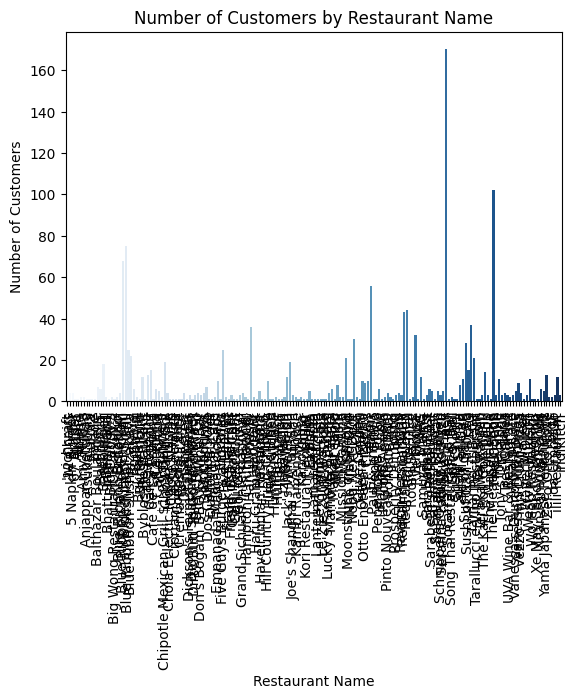

In [49]:
# Count the number of unique customers by restaurant name
customer_counts_by_restaurant = df.groupby('restaurant_name')['customer_id'].nunique().reset_index()

# Create a bar plot (count plot) to visualize the number of customers by restaurant name
sns.barplot(x='restaurant_name', y='customer_id', data=customer_counts_by_restaurant, palette="Blues")

# Title and labels
plt.title("Number of Customers by Restaurant Name")
plt.xlabel("Restaurant Name")
plt.ylabel("Number of Customers")
plt.xticks(rotation=90)  # Rotate x-axis labels for better readability
plt.show()

**Observations:**
- This distibution is highly right skewed.
- Most of the customers are going to very selected restaurants most of the time.

**13. Total Orders by Cuisine Type and Day of the Week**

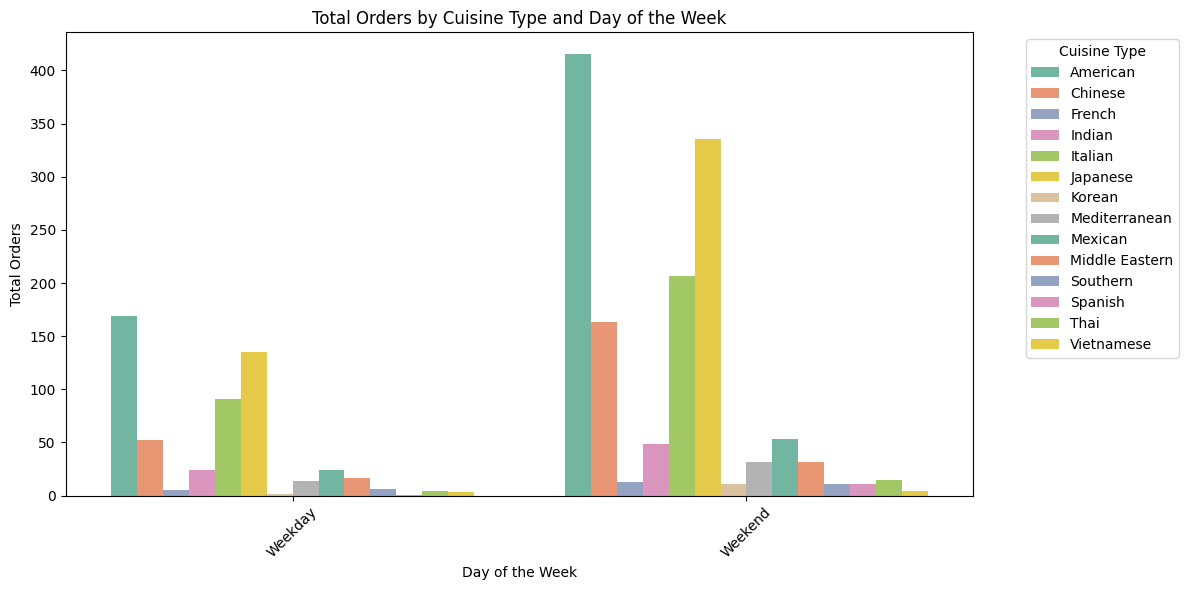

In [50]:
# Count the total number of orders by cuisine type and day of the week
total_orders_by_cuisine_day = df.groupby(['cuisine_type', 'day_of_the_week']).size().reset_index(name='total_orders')

# Create an empty canvas for the graph
plt.figure(figsize=(12, 6))

# Creates a bar plot
sns.barplot(x='day_of_the_week', y='total_orders', hue='cuisine_type', data=total_orders_by_cuisine_day, palette="Set2")

# Title and labels
plt.title("Total Orders by Cuisine Type and Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Total Orders")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.legend(title="Cuisine Type", bbox_to_anchor=(1.05, 1), loc='upper left')  # Position the legend outside
plt.tight_layout()
plt.show()

**Observations:**
- We can see that American cuisine is very famous throughout the week.
- Both on weekdays and weekends, we can see same types of cuisines are in same demand.

**14. Mean Delivery Time by Day of the Week**

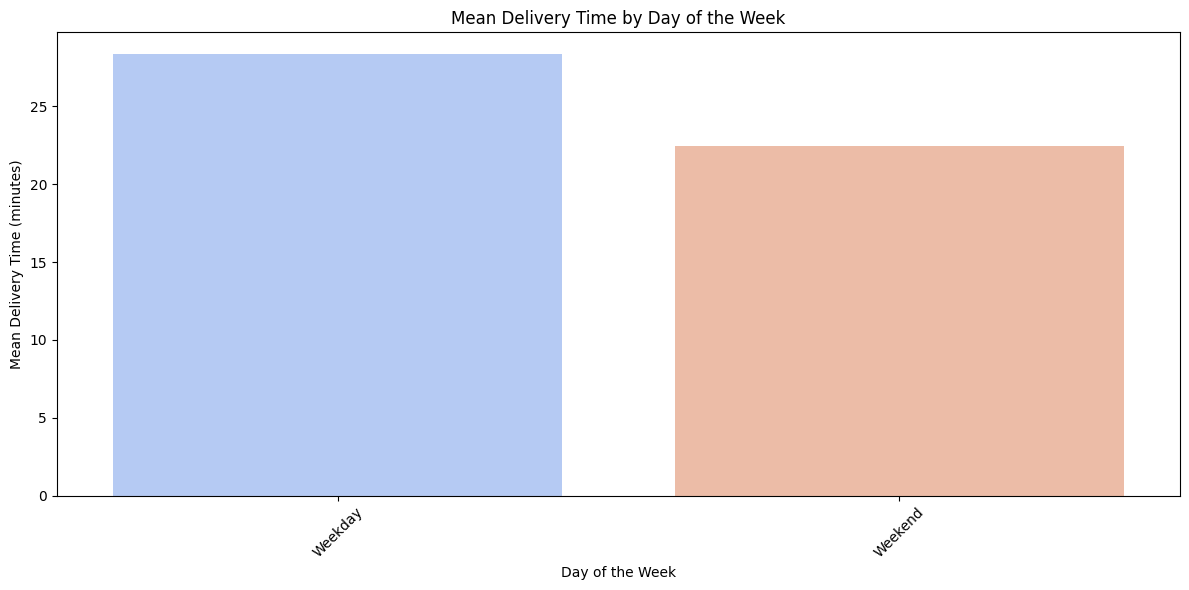

In [51]:
# Calculate the mean delivery time by day of the week
mean_delivery_time_by_day = df.groupby('day_of_the_week')['delivery_time'].mean().reset_index(name='mean_delivery_time')

# Create an empty canvas for the graph
plt.figure(figsize=(12, 6))

# Creates a bar plot
sns.barplot(x='day_of_the_week', y='mean_delivery_time', data=mean_delivery_time_by_day, palette="coolwarm")

# Title and labels
plt.title("Mean Delivery Time by Day of the Week")
plt.xlabel("Day of the Week")
plt.ylabel("Mean Delivery Time (minutes)")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

**Observations:**
- This one is interesting. Even though we have less orders on weekdays, it still take more time to deliver on weekdays.
- This is probably because of more traffic on weekedays as we have all the offices and other business opened.
- Another reason could be less number of riders available on weekdays to deliver the orders.

**15. Average Rating by Cuisine Type**

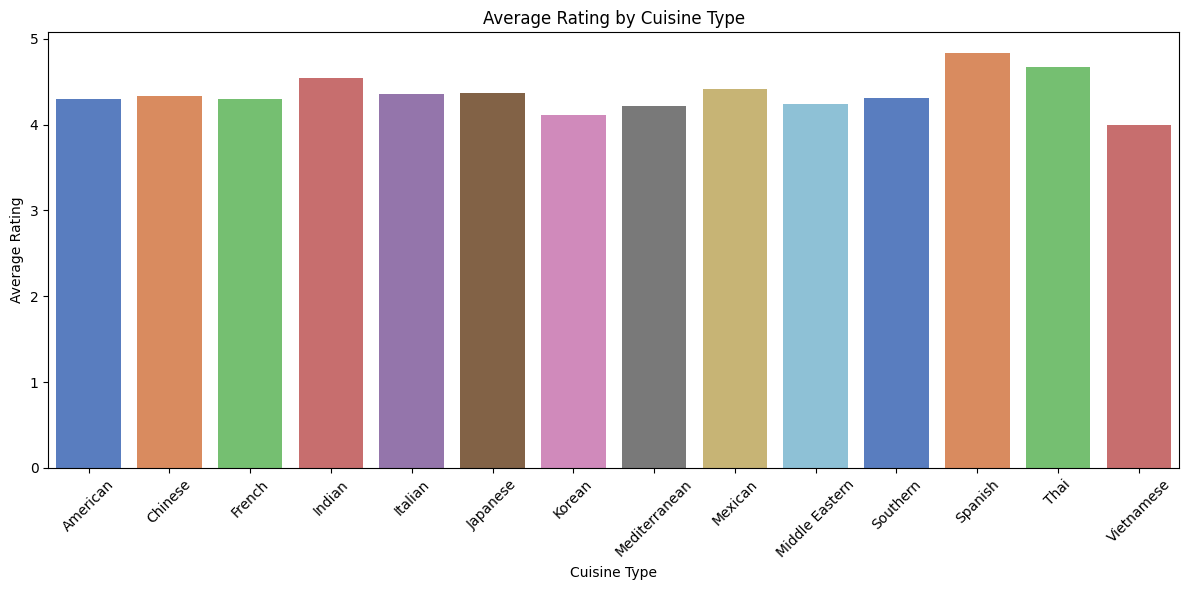

In [52]:
# Calculate the average rating by cuisine type
avg_rating_by_cuisine = df.groupby('cuisine_type')['rating'].mean().reset_index(name='average_rating')

# Create an empty canvas for the graph
plt.figure(figsize=(12, 6))

# Creates a bar plot
sns.barplot(x='cuisine_type', y='average_rating', data=avg_rating_by_cuisine, palette="muted")

# Title and labels
plt.title("Average Rating by Cuisine Type")
plt.xlabel("Cuisine Type")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

**Observations:**
- In terms of rating by cusine type, every cusine_type has got an average rating of more than 4 and thats pretty decent.

**16. Average Cost by Cuisine Type (Line Plot)**

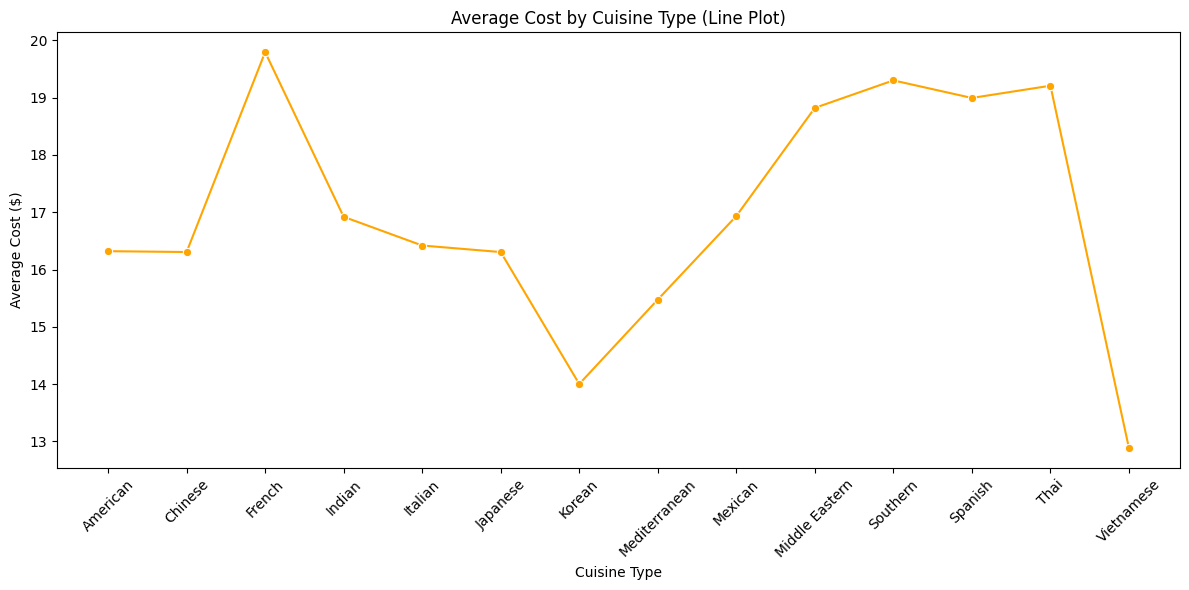

In [53]:
# Calculate the average cost by cuisine type
avg_cost_by_cuisine = df.groupby('cuisine_type')['cost_of_the_order'].mean().reset_index(name='average_cost')

# Create an empty canvas for the graph
plt.figure(figsize=(12, 6))

# Creates a line plot
sns.lineplot(x='cuisine_type', y='average_cost', data=avg_cost_by_cuisine, marker='o', color='orange')

# Title and labels
plt.title("Average Cost by Cuisine Type (Line Plot)")
plt.xlabel("Cuisine Type")
plt.ylabel("Average Cost ($)")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

**Observations:**
- From othe observations, we have seen that even though American, Italian and Chinese cuisines have the most orders, their average cost is not too high as compared to other cuisine types.
- This could be another reason why other costly cuisines have less orders.

**17. Average Food Preparation Time by Cuisine Type (Line Plot)**

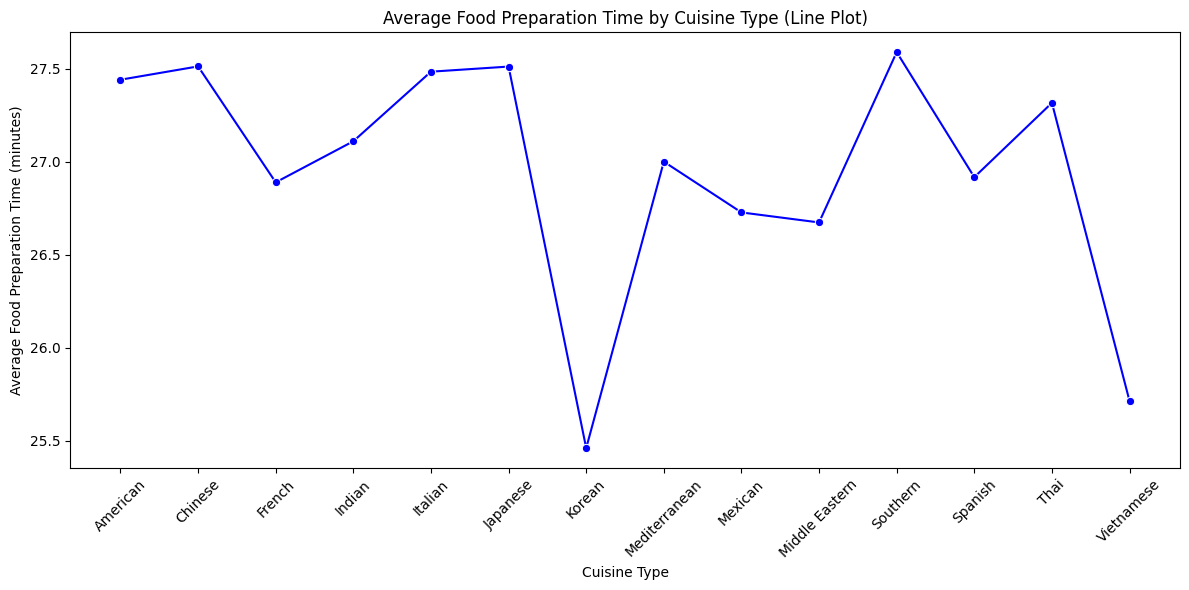

In [54]:
# Calculate the average food preparation time by cuisine type
avg_food_preparation_time_by_cuisine = df.groupby('cuisine_type')['food_preparation_time'].mean().reset_index(name='average_food_preparation_time')

# Create an empty canvas for the graph
plt.figure(figsize=(12, 6))

# Creates a line plot
sns.lineplot(x='cuisine_type', y='average_food_preparation_time', data=avg_food_preparation_time_by_cuisine, marker='o', color='b')

# Title and labels
plt.title("Average Food Preparation Time by Cuisine Type (Line Plot)")
plt.xlabel("Cuisine Type")
plt.ylabel("Average Food Preparation Time (minutes)")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

**Observations:**
- Mostly cuisines taking more than 26 minutes for preparation.
- We have outliers as Koran and Vietnamese who are taking less than 26 minutes.

**18. Average Rating by Cuisine Type (Line Plot)**

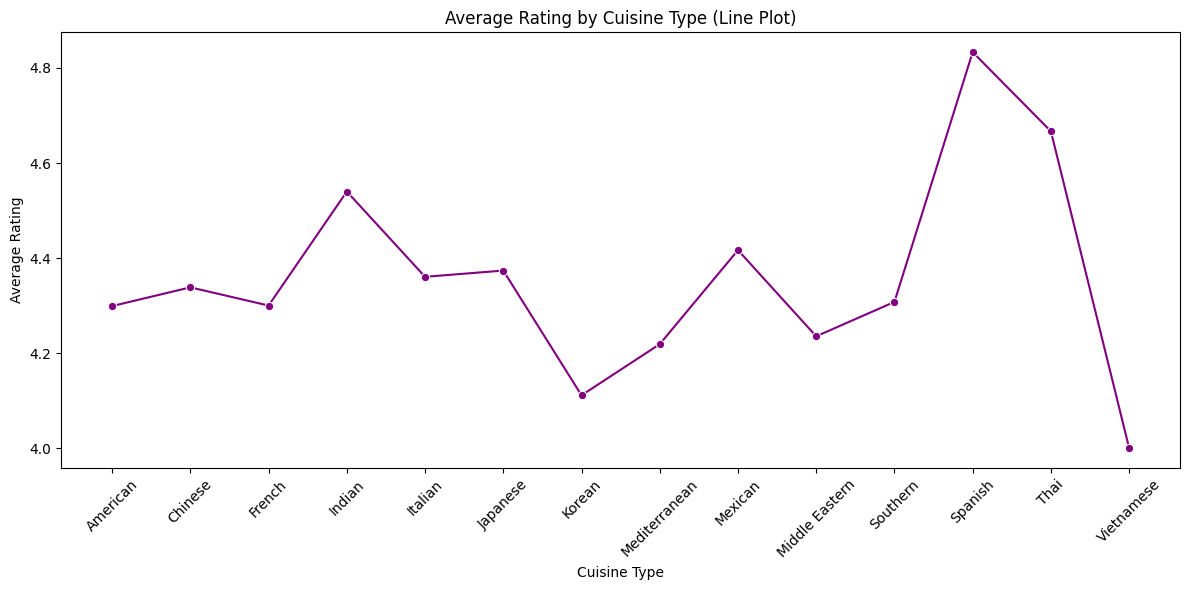

In [55]:
# Calculate the average rating by cuisine type
avg_rating_by_cuisine = df.groupby('cuisine_type')['rating'].mean().reset_index(name='average_rating')

# Create an empty canvas for the graph
plt.figure(figsize=(12, 6))

# Creates a line plot
sns.lineplot(x='cuisine_type', y='average_rating', data=avg_rating_by_cuisine, marker='o', color='purple')

# Title and labels
plt.title("Average Rating by Cuisine Type (Line Plot)")
plt.xlabel("Cuisine Type")
plt.ylabel("Average Rating")
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()
plt.show()

**Observations:**
- On average every cuisine has maintained an average rating above 4.
- We have Vietnamese has an outlier with relatively low rating than all others.

**19. Pair Plot of Food Preparation Time, Delivery Time, and Day of the Week**

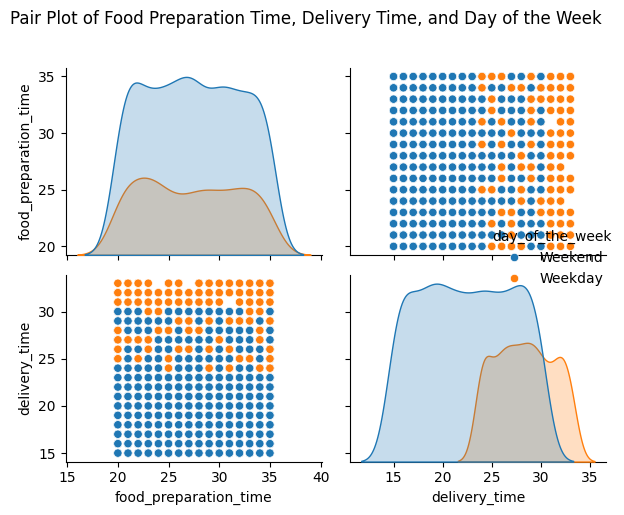

In [56]:
# Select the relevant columns for the pair plot
df_subset = df[['food_preparation_time', 'delivery_time', 'day_of_the_week']]

# Create a pair plot to visualize relationships between preparation time, delivery time, and day of the week
sns.pairplot(df_subset, hue='day_of_the_week')

# Title
plt.suptitle("Pair Plot of Food Preparation Time, Delivery Time, and Day of the Week", y=1.02)
plt.tight_layout()
plt.show()

**Observations:**

In this pair plot visualization:

- The food preparation time appears similar on both weekends and weekdays, but there might be a slight shift in density.
- The delivery time distribution shows a similar trend, but the weekend (blue) density seems to have a higher range.
- The scatter plots show relationships between food preparation time and delivery time.
- There seems to be no strong linear correlation between food preparation and delivery time, as points are spread out.
- However, weekend data (blue) seems to have slightly higher values for both food prep and delivery time.
- Weekends (blue dots) appear to have slightly longer preparation and delivery times.
- Weekdays (orange dots) are more clustered in the middle range, indicating more consistency in prep and delivery times.

Conclusion:
- This analysis suggests that food preparation and delivery take slightly longer on weekends.
- There's no strong correlation between food preparation time and delivery time.

### **Question 13:** The company wants to provide a promotional offer in the advertisement of the restaurants. The condition to get the offer is that the restaurants must have a rating count of more than 50 and the average rating should be greater than 4. Find the restaurants fulfilling the criteria to get the promotional offer. [3 marks]

In [57]:
'''
It needs multisteps to get to the restaurants who are eligible for the promotional offer.

First of all since it is based on ratings and we know the rating column has numeric values as well as a string value "Not given",
we will have to covert those string values to NaN values so that we can perform mathematical operations on the rating column.

Once we have the dataframe of ratings with all values converted to numeric values, we then apply the aggregation method to calculate
count and mean of ratings for each restaurant.

Last, we filter the records where the count of ratings is greater than 50 and the average rating is greater than 4 and those are the
eligibile restaurants for the promotional offer.
'''

# Convert the 'rating' column to numeric, forcing errors (like "Not Rated") to NaN
df['rating'] = pd.to_numeric(df['rating'], errors='coerce')

# Group by 'restaurant_name' and calculate the count of ratings and the average rating
restaurant_ratings = df.groupby('restaurant_name')['rating'].agg(['count', 'mean'])

# Rename the columns
restaurant_ratings.columns = ['Rating Count', 'Rating Mean']

# Filter restaurants with more than 50 ratings and an average rating greater than 4
offer_eligible_restaurants = restaurant_ratings[(restaurant_ratings['Rating Count'] > 50) & (restaurant_ratings['Rating Mean'] > 4)]

# Print the filtered results
print(offer_eligible_restaurants)

                           Rating Count  Rating Mean
restaurant_name                                     
Blue Ribbon Fried Chicken            64     4.328125
Blue Ribbon Sushi                    73     4.219178
Shake Shack                         133     4.278195
The Meatball Shop                    84     4.511905


In [ ]:
# showing the total number of unique restaurants to support my observations below.
unique_restaurants = df['restaurant_name'].nunique()
print(f"Total unique restaurants: {unique_restaurants}")

Total unique restaurants: 178


#### Observations:
- It is not good that out of total 178 unique restaurants, only 4 were eligible for this offer.
- This is something business should care about dive deeper to improve this in future.


### **Question 14:** The company charges the restaurant 25% on the orders having cost greater than 20 dollars and 15% on the orders having cost greater than 5 dollars. Find the net revenue generated by the company across all orders. [3 marks]

In [59]:
'''
In this problem we are defining a helper function calculate_revenue for each order.
It is efficient to use a separate function to do the same job multiple times for us.

Therefore, the calculate_revenue function will take one row from the dataframe as its argument
and return the revenue for that single order.

We are using apply() method of the dataframe which loops through every row in the dataframe
and calls the calculate_revenue function on it.

The result of each calculate_revenue call is stored as a new data point in the revenue dataframe.

Finally, we simply call the sum() method of the revenue dataframe to get the net revenue generated by the company.
'''

# Helper Function to calculate revenue
# This function applies 25%, 15% or 0% to the cost of the orders
def calculate_revenue(row):
    if row['cost_of_the_order'] > 20:
        return row['cost_of_the_order'] * 0.25  # 25% fee for orders > 20 dollars
    elif row['cost_of_the_order'] > 5:
        return row['cost_of_the_order'] * 0.15  # 15% fee for orders > 5 dollars but <= 20 dollars
    else:
        return 0  # No fee for orders <= 5 dollars

# Apply the function to each row in the DataFrame to calculate the revenue for each order
df['revenue'] = df.apply(calculate_revenue, axis=1)

# Calculate the total net revenue generated by the company across all orders
net_revenue = df['revenue'].sum()

print(f"Net Revenue: ${net_revenue:.2f}")

Net Revenue: $6166.30


#### Observations:
- With the current charges, the revenue is landed on 6166.30 dollars.
- I think this is a reasonable charges that company is chargining on these costs of the orders.

### **Question 15:** The company wants to analyze the total time required to deliver the food. What percentage of orders take more than 60 minutes to get delivered from the time the order is placed? (The food has to be prepared and then delivered.) [2 marks]

In [60]:
'''
This is another multisteps problem where we first calculate the total time of each order by adding food preparation time and delivery time.
Then we filter those records where total time is greater than 60
Finally we can calculate the percentage of orders that take more than 60 minutes to get delivered.
'''

# Total time (food preparation time + delivery time)
df['total_time'] = df['food_preparation_time'] + df['delivery_time']

# Filter orders where total time is greater than 60 minutes
orders_above_60 = df[df['total_time'] > 60]

# Percentage of orders with total time greater than 60 minutes
percentage_above_60 = (len(orders_above_60) / len(df)) * 100

print(f"{percentage_above_60:.2f}% of the orders take more than 60 minutes to get delivered from the time the order is placed.")

10.54% of the orders take more than 60 minutes to get delivered from the time the order is placed.


#### Observations:
-- 10.54% of total 1898 orders is around 200 orders which is taking above 60 minutes.
-- I believe its not bad but in general it should be identified why even an order takes more than 60 minutes.

### **Question 16:** The company wants to analyze the delivery time of the orders on weekdays and weekends. How does the mean delivery time vary during weekdays and weekends? [2 marks]

In [61]:
'''
In this problem, we are just creating a new dataframe to categorize orders into weekdays and weekends.
Then we are simply creating a mean delivery time column for each category by using groupby() method.
'''

# Create a new column to categorize orders into weekdays and weekends
df['day_category'] = df['day_of_the_week']

# Calculate the mean delivery time for weekdays and weekends
mean_delivery_time = df.groupby('day_category')['delivery_time'].mean().to_frame()

print(mean_delivery_time)

# You can see in the output that there is almost 6 minutes difference in the delivery time during Weekends vs Weekdays

              delivery_time
day_category               
Weekday           28.340037
Weekend           22.470022


#### Observations:

- It varies such that orders on weekdays take longer than weekends.
- It could be due to more traffic on weekdays as businesses are opened on weekdays vs weekends

### Conclusion and Recommendations

### **Question 17:** What are your conclusions from the analysis? What recommendations would you like to share to help improve the business? (You can use cuisine type and feedback ratings to drive your business recommendations.) [6 marks]

### Conclusions:
- Quality issues causing some restaurants to have consistently lower ratings.
- Due to frequent skip of ratings, the feedback collection is impacted.
- Weekday deliveries take longer than weekend deliveries, possibly due to traffic or restaurant operations.
- Some restaurants may have higher food preparation times, leading to slower overall delivery.
- Revenue can be improved by increasing high-value orders because company earns higher commission (25%) on expensive orders
- The most frequently ordered restaurants and cuisines can help identify customer preferences.
- Certain cuisines may perform better on weekends vs. weekdays, indicating demand patterns.


### Recommendations:

- Encourage customers to leave ratings by offering small incentives (e.g., discount on next order).
- Consider partnering with faster delivery services for restaurants with long delivery times.
- Offer discounts for leaving reviews to encourage feedback.
- Automatically follow up with customers after delivery to request a rating
- Introduce a reward system where customers earn points for every order, redeemable for discounts.
- Use past order history to recommend favorite cuisines or combo deals.
- If weekday deliveries are slower, partner with more drivers during peak hours.
- Offer express delivery for premium customers.
- Offer discounts or promotions on orders above $20 to boost revenue.
- Recommend high-margin items during checkout to increase average order value.
- If weekend demand is high, consider special offers on weekdays to balance order volume.
- Encourage pre-orders for peak hours to improve service speed.



---